<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_10_SBIBM_Hybrid_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 10 — Benchmarking hNPE and hNDE on `sbibm`

Exercises 5--9 used simulators whose analytic densities were available to us. That was essential while the hybrid constructions, weighted Asimov samples, neural importance sampling, and the dual Bayesian hNPE--hNDE model were being developed. This exercise deliberately removes that safety net during training.

The methods are tested on the public benchmark introduced in [*Benchmarking Simulation-Based Inference*](https://arxiv.org/abs/2101.04653) by Lueckmann *et al.* The official [`sbibm` framework](https://github.com/sbi-benchmark/sbibm) supplies the simulators, ten fixed observations per task, and 10,000 reference-posterior samples per observation. The official [result tables](https://github.com/sbi-benchmark/results/tree/main/benchmarking_sbi/results) supply the numbers to beat.

The target is deliberately ambitious: at a fixed simulator budget, the ratio-corrected posterior should obtain a mean classifier two-sample-test accuracy (C2ST) below the best result reported for REJ-ABC, SMC-ABC, NLE, NPE, NRE, SNLE, SNPE, and SNRE. Ideal posterior closure corresponds to C2ST $=0.5$.

The default **challenge** profile uses the successful recipe from Exercises 5 and 9: rational-quadratic spline flows, large ratio networks, a factor-100 learning-rate reduction every ten epochs, raw (uncalibrated) ratio ensembles, validation-loss screening, defensive support, and two-fold cross-fitting. It is a long GPU run by design.


In [1]:
## ============================================================================
# Google Colab setup — safe to re-run and a no-op off Colab.
# ============================================================================
import os, sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_DRIVE = True


def run(*args, env=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    # This backward-compatible working directory preserves models from Exercises 4--9.
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"
    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)
    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )
    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    # Colab already provides PyTorch, NumPy, SciPy, pandas, and scikit-learn.
    # Installing sbibm without its historical algorithm dependencies avoids
    # downgrading the modern Colab environment; only the task/metric dependencies
    # used below are added explicitly. Version 1.1.0 is the latest official
    # sbibm release and includes the corrected Gaussian Mixture simulator.
    run(sys.executable, "-m", "pip", "install", "-q", "nflows", "pyro-ppl")
    run(
        sys.executable, "-m", "pip", "install", "-q", "--no-deps",
        "sbibm==1.1.0",
    )
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)
else:
    for candidate in [
        Path.cwd(),
        Path.cwd() / "workshops" / "ml4hep_tifr_colab",
    ]:
        if (candidate / "utils_benchmark.py").exists():
            sys.path.insert(0, str(candidate.resolve()))
            break

print("Working directory:", Path.cwd())


Mounted at /content/drive
Working directory: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


In [2]:
import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sbibm
import torch
from IPython.display import display
from scipy.special import logsumexp

from utils_benchmark import (
    PAPER_ALGORITHMS,
    TASK_RECOMMENDATIONS,
    best_published_targets,
    compare_with_paper,
    draw_hybrid_posterior,
    effective_sample_size,
    evaluate_observation_suite,
    evaluate_posterior_samples,
    load_or_simulate_bank,
    load_paper_results,
    summarize_our_results,
    summarize_paper_results,
    task_recommendation_table,
    train_hybrid_benchmark_model,
)
from utils_hnpe import ratio_classifier_ensemble_logit, sample_spline_flow
from utils_plotting import export_standalone_figure_script

SEED = 23102026
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("sbibm version:", sbibm.__version__)
print("Using device:", device)


sbibm version: 1.1.0
Using device: cuda


## 1. What is in the benchmark?

The paper defines ten tasks, obtained from eight simulator families. Gaussian Linear and SLCP each have a second variant, and the Bernoulli GLM is exposed both through ten sufficient statistics and through the 100 raw binary observations.

The hNDE factorization used here has a continuous normalizing flow $q_\eta(x)$ as its observation reference. It is therefore most natural for the six continuous tasks. The posterior-side hNPE remains applicable when $x$ is discrete or very high-dimensional because $x$ is conditioning information rather than the density-estimation target. A discrete hNDE could be built with an autoregressive probability-mass model, but silently applying a continuous flow to binary data would not be an exact density construction.

The SIR and Lotka--Volterra implementations use `diffeqtorch` and Julia. Their observations and reference posteriors are included in `sbibm`, but generating new simulations requires the optional Julia backend; they are not the first Colab targets.


In [3]:
recommendations = task_recommendation_table()
display(
    recommendations[
        [
            "task", "dim_parameters", "dim_data", "data_type",
            "recommended_method", "colab_status", "reason",
        ]
    ].style.hide(axis="index")
)


task,dim_parameters,dim_data,data_type,recommended_method,colab_status,reason
gaussian_linear,10,10,continuous,dual hNPE--hNDE,ready,A normalization and scaling control; the posterior is nearly solved.
gaussian_linear_uniform,10,10,"continuous, bounded parameters",dual hNPE--hNDE,ready,Tests exact bounded support through the parameter logit transform.
gaussian_mixture,2,2,continuous mixture,dual hNPE--hNDE,ready,A compact heavy-tail test; corrected v1.1 benchmark results are used.
two_moons,2,2,"continuous, multimodal",dual hNPE--hNDE,primary target,The paper's diagnostic example has curved modes and clear headroom.
slcp,5,8,"continuous, four-mode posterior",dual hNPE--hNDE,stretch target,The best published mean C2ST at 100k is still far from 0.5.
slcp_distractors,5,100,continuous with 92 distractors,hNPE; optional dual,expensive,hNPE avoids making a 100-dimensional observation flow the bottleneck.
bernoulli_glm,10,10,discrete-derived sufficient statistics,hNPE,ready,A conditional posterior can use the summaries directly; a continuous hNDE reference is not an exact probability-mass model.
bernoulli_glm_raw,10,100,binary,hNPE,expensive,The raw observation is discrete and 100-dimensional.
sir,2,10,count time series,hNPE,Julia backend required,The official simulator uses diffeqtorch/Julia; hNDE would need a discrete or dequantized reference model.
lotka_volterra,4,20,count time series,hNPE,Julia backend required,The official simulator uses diffeqtorch/Julia and is costly.


## 2. The two hybrid factorizations

Forward simulations are drawn from a design distribution equal to the task prior, $\rho(\theta)=\pi(\theta)$.

### Posterior route: hNPE

A conditional spline flow first estimates $q_\phi(\theta\mid x)$. Defensive support is supplied by

$$
q_{\phi,\epsilon}(\theta\mid x)
=(1-\epsilon)q_\phi(\theta\mid x)+\epsilon\rho(\theta).
$$

A balanced classifier separates joint samples $(\theta,x)\sim\rho(\theta)p(x\mid\theta)$ from samples $x\sim p_\rho(x)$, $\theta\sim q_{\phi,\epsilon}(\theta\mid x)$. Its likelihood ratio is

$$
r_{\rm P}(\theta,x)
=\frac{p(\theta,x)}{p_\rho(x)q_{\phi,\epsilon}(\theta\mid x)}
=\frac{p(\theta\mid x)}{q_{\phi,\epsilon}(\theta\mid x)}.
$$

Consequently, samples from the defensive NPE proposal weighted by $r_{\rm P}$ represent the posterior.

### Likelihood route: hNDE

An unconditional spline is trained on the prior predictive,

$$q_\eta(x)\simeq p_\rho(x)=\int\rho(\theta)p(x\mid\theta)\,d\theta.$$

A second balanced classifier separates the joint distribution from $\rho(\theta)q_\eta(x)$ and estimates

$$
r_{\rm L}(x;\theta)=\frac{p(x\mid\theta)}{q_\eta(x)},
\qquad
\widehat p(x\mid\theta)=q_\eta(x)r_{\rm L}(x;\theta).
$$

For a fixed observation the factor $q_\eta(x_o)$ cancels, so the hNDE posterior weights are proportional to $\rho(\theta)r_{\rm L}(x_o;\theta)/q_{\phi,\epsilon}(\theta\mid x_o)$. The predeclared **dual consensus** is the normalized geometric mean of the hNPE and hNDE importance weights. If both estimators are exact, all three routes are identical; at finite training size, averaging their log-density errors can be beneficial.

Bounded parameters are mapped through a logit and positive parameters through a logarithm before flow training. This builds the exact prior support into the NPE instead of asking the residual classifier to repair samples outside it.


## 3. What has to be beaten?

The paper evaluates 10,000 inferred posterior samples against 10,000 reference samples with a z-scored, five-fold neural classifier two-sample test. C2ST $=0.5$ is ideal and lower is better. Results are averaged over ten fixed observations, with simulation budgets of $10^3$, $10^4$, and $10^5$ **per trained inference model**.

The official Gaussian Mixture simulator had a bug that was corrected in `sbibm` v1.1.0. Exercise 10 uses the official rerun table for that task and the manuscript table for the other nine tasks.


In [4]:
paper_results = load_paper_results(corrected_gaussian_mixture=True)
targets_100k = best_published_targets(paper_results, num_simulations=100_000)
display(
    targets_100k[
        ["task", "algorithm", "mean", "ci95"]
    ].rename(
        columns={
            "algorithm": "best published algorithm",
            "mean": "mean C2ST",
            "ci95": "95% CI",
        }
    ).style.format({"mean C2ST": "{:.4f}", "95% CI": "{:.4f}"}).hide(axis="index")
)


task,best published algorithm,mean C2ST,95% CI
bernoulli_glm,SNLE,0.5218,0.0078
bernoulli_glm_raw,SNRE,0.5525,0.0091
gaussian_linear,NPE,0.5060,0.0025
gaussian_linear_uniform,NLE,0.5065,0.0027
gaussian_mixture,SNRE,0.5310,0.0110
lotka_volterra,SNLE,0.6951,0.0635
sir,SNRE,0.5472,0.0162
slcp,SNLE,0.5781,0.0182
slcp_distractors,SNRE,0.7662,0.0318
two_moons,SNPE,0.5298,0.0159


## 4. Choose the campaign

Three profiles are supplied:

- `quick`: a valid $10^4$-simulation comparison on one observation, useful for checking a new runtime;
- `paper`: $10^5$ simulations, four ratio members, one independent flow/ratio split, and all ten observations;
- `challenge`: $10^5$ simulations, four members per fold and two-fold cross-fitting. Every simulated event is used once for flow training and once for ratio training across the two folds, but the bank still contains exactly $10^5$ unique simulator calls.

Two Moons is the default first target. SLCP is the most interesting stretch target: the best published mean C2ST at $10^5$ is about 0.58, leaving a much larger gap to ideal closure. The Gaussian tasks are valuable controls but already sit close to the irreducible finite-C2ST floor.


In [5]:
PROFILE = "challenge"  # "quick", "paper", or "challenge"
TASK_NAME = "two_moons"
LOAD_IF_AVAILABLE = True

PROFILES = {
    "quick": {
        "num_simulations": 10_000,
        "num_folds": 1,
        "ensemble_size": 2,
        "flow_epochs": 20,
        "ratio_epochs": 30,
        "n_proposal": 50_000,
        "observations": [1],
    },
    "paper": {
        "num_simulations": 100_000,
        "num_folds": 1,
        "ensemble_size": 4,
        "flow_epochs": 50,
        "ratio_epochs": 70,
        "n_proposal": 180_000,
        "observations": list(range(1, 11)),
    },
    "challenge": {
        "num_simulations": 100_000,
        "num_folds": 2,
        "ensemble_size": 4,
        "flow_epochs": 60,
        "ratio_epochs": 80,
        "n_proposal": 250_000,
        "observations": list(range(1, 11)),
    },
}
campaign = PROFILES[PROFILE]
NUM_SIMULATIONS = campaign["num_simulations"]
N_CROSSFIT_FOLDS = campaign["num_folds"]
RATIO_ENSEMBLE_SIZE = campaign["ensemble_size"]
N_PROPOSAL = campaign["n_proposal"]
OBSERVATIONS = campaign["observations"]
N_POSTERIOR_SAMPLES = 10_000
DEFENSIVE_EPSILON = 0.02

DUAL_READY_TASKS = {
    "gaussian_linear",
    "gaussian_linear_uniform",
    "gaussian_mixture",
    "two_moons",
    "slcp",
}
TRAIN_HNDE = TASK_NAME in DUAL_READY_TASKS
HEADLINE_METHOD = "dual hNPE--hNDE" if TRAIN_HNDE else "hNPE"

FLOW_MODEL_CONFIG = {
    "n_coupling_layers": 12,
    "hidden_features": 512,
    "hidden_layers": 4,
    "spline_num_bins": 16,
    "spline_tail_bound": 5.0,
    "dropout_probability": 0.0,
}
FLOW_TRAINING_CONFIG = {
    "batch_size": 1024,
    "n_epochs": campaign["flow_epochs"],
    "learning_rate": 1.0e-3,
    "lr_scheduler_factor": 0.2,
    "lr_scheduler_patience": 3,
    "min_learning_rate": 1.0e-10,
    "validation_fraction": 0.2,
    "patience": 15,
    "gradient_clip": 5.0,
}
RATIO_MODEL_CONFIG = {
    "hidden_features": 1024,
    "hidden_layers": 5,
    "dropout_probability": 0.0,
}
RATIO_TRAINING_CONFIG = {
    "batch_size": 2048,
    "n_epochs": campaign["ratio_epochs"],
    "learning_rate": 1.0e-3,
    "lr_scheduler": "step",
    "lr_scheduler_factor": 0.01,
    "lr_scheduler_patience": 10,
    "validation_fraction": 0.2,
    "patience": 40,
    "gradient_clip": 5.0,
}

RUN_TAG = f"{PROFILE}_budget{NUM_SIMULATIONS}_spline16_ensemble{RATIO_ENSEMBLE_SIZE}_v1"
MODEL_DIR = Path("models_exercise10_sbibm") / TASK_NAME / RUN_TAG
CACHE_DIR = Path("dataframes_exercise10_sbibm")
RESULT_DIR = Path("exercise10_benchmark_results")
FIGURE_SCRIPT_DIR = Path("exercise10_figures_scripts") / TASK_NAME / RUN_TAG
for directory in (MODEL_DIR, CACHE_DIR, RESULT_DIR, FIGURE_SCRIPT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    "profile": PROFILE,
    "task": TASK_NAME,
    "simulator_budget": NUM_SIMULATIONS,
    "crossfit_folds": N_CROSSFIT_FOLDS,
    "ratio_members_per_fold": RATIO_ENSEMBLE_SIZE,
    "train_hnde": TRAIN_HNDE,
    "headline_method": HEADLINE_METHOD,
    "observations": OBSERVATIONS,
}, indent=2))


{
  "profile": "challenge",
  "task": "two_moons",
  "simulator_budget": 100000,
  "crossfit_folds": 2,
  "ratio_members_per_fold": 4,
  "train_hnde": true,
  "headline_method": "dual hNPE--hNDE",
  "observations": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ]
}


## 5. Acquire the task and the exact-budget simulation bank

`sbibm` packages each simulator together with the ten observations and their reference posteriors. Training data are not a fixed download: they are generated from the official prior and simulator. The compressed bank below is cached on Drive, so restarting Colab never incurs accidental additional simulator calls.

No reference-posterior sample is used for training, model selection, calibration, or outlier screening. It enters only after all inference weights have been fixed.


In [6]:
try:
    task = sbibm.get_task(TASK_NAME)
except (ImportError, ModuleNotFoundError) as exc:
    if TASK_NAME in {"sir", "lotka_volterra"}:
        raise RuntimeError(
            "This official ODE task requires diffeqtorch and a working Julia "
            "DifferentialEquations backend. Start with a non-ODE task in Colab."
        ) from exc
    raise

print(
    f"{task.name_display}: dim(theta)={task.dim_parameters}, "
    f"dim(x)={task.dim_data}, observations={task.num_observations}"
)
simulation_bank = load_or_simulate_bank(
    task,
    NUM_SIMULATIONS,
    cache_path=CACHE_DIR / f"{TASK_NAME}_prior_predictive_{NUM_SIMULATIONS}_seed{SEED}.npz",
    seed=SEED,
    chunk_size=20_000,
)
assert simulation_bank.num_simulations == NUM_SIMULATIONS
print("Unique simulator calls used for all neural objects:", simulation_bank.num_simulations)


Two Moons: dim(theta)=2, dim(x)=2, observations=10
Saved exactly 100,000 simulations to dataframes_exercise10_sbibm/two_moons_prior_predictive_100000_seed23102026.npz
Unique simulator calls used for all neural objects: 100000


## 6. Train the hybrid model

Within each fold, half of the bank trains both reference flows and the other half trains both corrective ratios. This separation prevents a residual classifier from learning flow overfitting on the same events. With two folds, the roles are swapped and the posterior estimates are mixed with equal weight.

Each ratio ensemble is combined by averaging positive ratios, not logits, and no post-hoc calibration is applied. A member whose best validation BCE is a clear outlier relative to the ensemble is automatically retrained with a new seed. This is the same stability logic used in the earlier exercises and does not inspect benchmark reference samples.


In [7]:
hybrid_models = []
for fold in range(N_CROSSFIT_FOLDS):
    print("\n" + "=" * 88)
    print(f"TRAINING CROSSFIT FOLD {fold + 1}/{N_CROSSFIT_FOLDS}")
    print("=" * 88)
    hybrid_models.append(
        train_hybrid_benchmark_model(
            task,
            simulation_bank,
            model_dir=MODEL_DIR,
            flow_model_config=FLOW_MODEL_CONFIG,
            flow_training_config=FLOW_TRAINING_CONFIG,
            ratio_model_config=RATIO_MODEL_CONFIG,
            ratio_training_config=RATIO_TRAINING_CONFIG,
            device=device,
            seed=SEED + 100_000 * fold,
            ensemble_size=RATIO_ENSEMBLE_SIZE,
            defensive_epsilon=DEFENSIVE_EPSILON,
            flow_fraction=0.5,
            fold=fold,
            train_hnde=TRAIN_HNDE,
            load_if_available=LOAD_IF_AVAILABLE,
            retrain_outliers=True,
        )
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"Trained {len(hybrid_models)} fold(s); simulator calls remain {NUM_SIMULATIONS:,}.")



TRAINING CROSSFIT FOLD 1/2
Training conditional quadratic-spline flow on 40,000 rows
  epoch 01/60: train=1.6993, validation=1.4060
  epoch 02/60: train=1.0386, validation=1.0375
  epoch 03/60: train=0.7764, validation=0.7434
  epoch 04/60: train=0.6783, validation=0.5442
  epoch 05/60: train=0.5276, validation=0.4787
  epoch 06/60: train=0.4721, validation=0.2672
  epoch 07/60: train=0.4213, validation=0.4261
  epoch 08/60: train=0.4096, validation=0.4433
  epoch 09/60: train=0.2523, validation=0.1629
  epoch 10/60: train=0.2938, validation=0.3327
  epoch 11/60: train=0.1881, validation=0.1471
  epoch 12/60: train=0.1766, validation=0.1716
  epoch 13/60: train=0.2600, validation=0.1217
  epoch 14/60: train=0.0743, validation=0.6168
  epoch 15/60: train=0.1232, validation=0.4617
  epoch 16/60: train=0.0368, validation=0.1179
  epoch 17/60: train=0.0763, validation=0.1489
  epoch 18/60: train=0.0424, validation=0.3240
  epoch 19/60: train=0.0555, validation=0.0625
  epoch 20/60: train=

Wrote standalone figure script: exercise10_figures_scripts/two_moons/challenge_budget100000_spline16_ensemble4_v1/training_histories.py


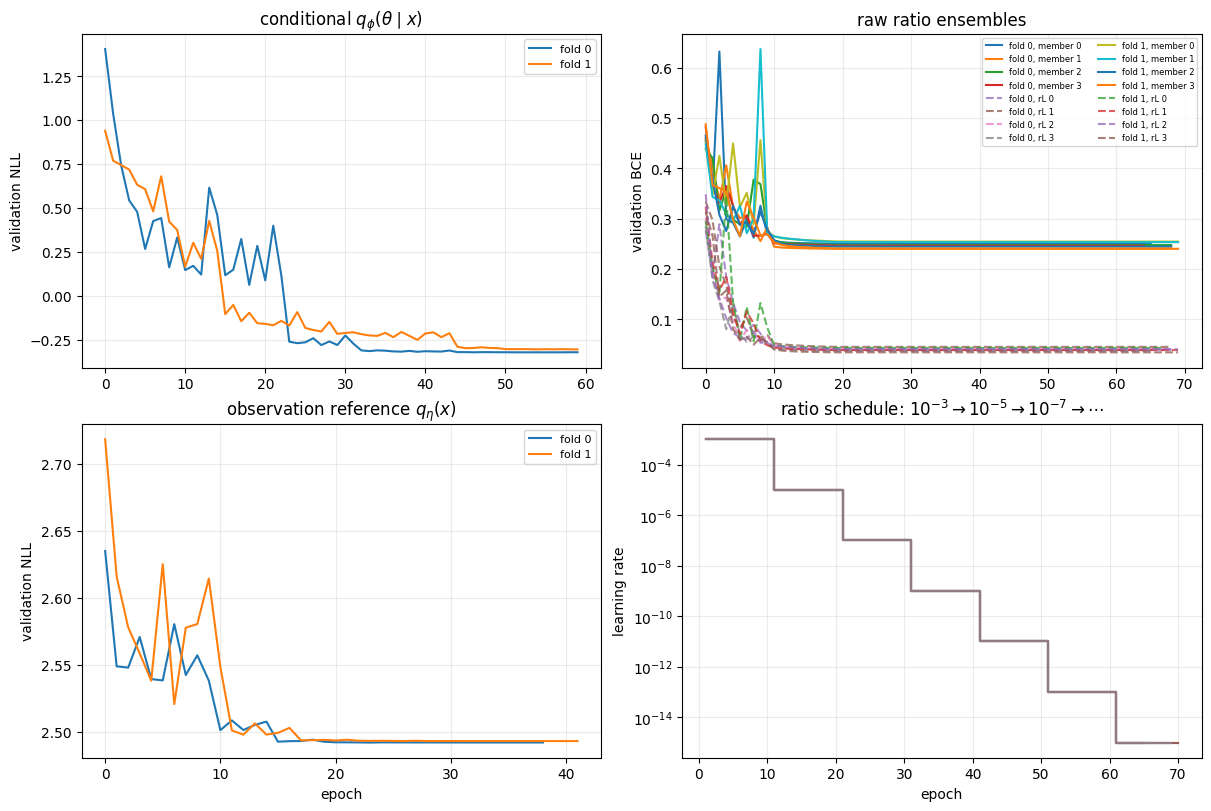

In [8]:
def export_exercise10_figure(fig, script_name):
    return export_standalone_figure_script(
        fig,
        script_name=script_name,
        output_dir=FIGURE_SCRIPT_DIR,
    )


fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for model in hybrid_models:
    fold_label = f"fold {model.fold}"
    axes[0, 0].plot(
        model.q_phi.get("history", {}).get("validation", []),
        label=fold_label,
    )
    for member, pack in enumerate(model.r_p_ensemble):
        label = f"{fold_label}, member {member}"
        history = pack.get("history", {})
        axes[0, 1].plot(history.get("validation", []), label=label)
        axes[1, 1].step(
            np.arange(1, len(history.get("learning_rate", [])) + 1),
            history.get("learning_rate", []),
            where="post",
            alpha=0.8,
        )
    if model.has_hnde:
        axes[1, 0].plot(
            model.q_eta.get("history", {}).get("validation", []),
            label=fold_label,
        )
        for member, pack in enumerate(model.r_l_ensemble):
            axes[0, 1].plot(
                pack.get("history", {}).get("validation", []),
                ls="--",
                alpha=0.75,
                label=f"{fold_label}, rL {member}",
            )

axes[0, 0].set(title=r"conditional $q_\phi(\theta\mid x)$", ylabel="validation NLL")
axes[1, 0].set(title=r"observation reference $q_\eta(x)$", xlabel="epoch", ylabel="validation NLL")
axes[0, 1].set(title="raw ratio ensembles", ylabel="validation BCE")
axes[1, 1].set(
    title=r"ratio schedule: $10^{-3}\to10^{-5}\to10^{-7}\to\cdots$",
    xlabel="epoch",
    ylabel="learning rate",
    yscale="log",
)
for ax in axes.flat:
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
if model.has_hnde:
    axes[1, 0].legend(fontsize=8)
axes[0, 1].legend(fontsize=6, ncol=2)
export_exercise10_figure(fig, "training_histories")
plt.show()


## 7. First untouched observation: posterior closure

The first official observation is now presented to the amortized model. Four posterior approximations are constructed:

1. the spline NPE reference;
2. the ratio-corrected hNPE;
3. the hNDE likelihood route, using the same defensive proposal only as an importance sampler;
4. the predeclared dual consensus.

The benchmark reference samples are loaded only after these samples have been drawn. The exact `sbibm.metrics.c2st` implementation is used with its paper settings: z-scoring, five folds, and 10,000 samples from each distribution.


In [9]:
NUM_OBSERVATION = 1
observation = task.get_observation(num_observation=NUM_OBSERVATION)
posterior_draws = draw_hybrid_posterior(
    hybrid_models,
    observation.detach().cpu().numpy(),
    n_proposal=N_PROPOSAL,
    n_samples=N_POSTERIOR_SAMPLES,
    seed=SEED + 700,
)
display(posterior_draws.diagnostics.style.format(precision=4).hide(axis="index"))

observation1_metrics = evaluate_posterior_samples(
    task,
    NUM_OBSERVATION,
    posterior_draws.samples,
    seed=SEED + 701,
)
observation1_metrics["num_simulations"] = NUM_SIMULATIONS
display(
    observation1_metrics.sort_values("C2ST")
    .style.format({"C2ST": "{:.4f}"})
    .hide(axis="index")
)


fold,proposal_rows,E_q_rP,hNPE_hNDE_log_weight_rms,ESS_hNPE,ESS_fraction_hNPE,ESS_hNDE,ESS_fraction_hNDE,ESS_dual hNPE--hNDE,ESS_fraction_dual hNPE--hNDE
0,125000,1.0591,61.4914,42763.2127,0.1711,9148.9107,0.0366,35975.4816,0.1439
1,125000,0.9787,67.5838,42763.2127,0.1711,9148.9107,0.0366,35975.4816,0.1439


task,num_observation,algorithm,C2ST,num_simulations
two_moons,1,dual hNPE--hNDE,0.5228,100000
two_moons,1,hNDE,0.5432,100000
two_moons,1,hNPE,0.5460,100000
two_moons,1,NPE reference,0.8885,100000


Wrote standalone figure script: exercise10_figures_scripts/two_moons/challenge_budget100000_spline16_ensemble4_v1/observation1_posterior_closure.py


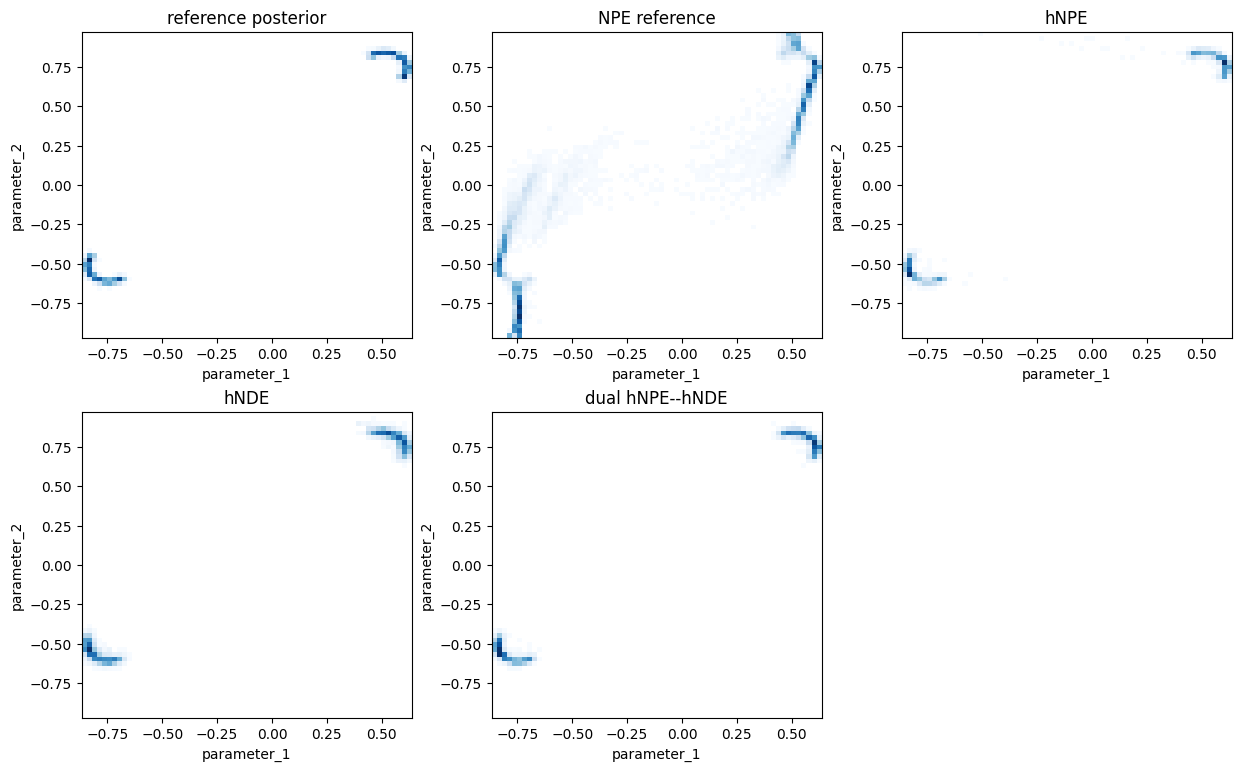

In [10]:
reference_samples = (
    task.get_reference_posterior_samples(num_observation=NUM_OBSERVATION)
    .detach().cpu().numpy()
)
parameter_labels = task.get_labels_parameters()

if task.dim_parameters == 2:
    methods = ["NPE reference", "hNPE"]
    if TRAIN_HNDE:
        methods.extend(["hNDE", "dual hNPE--hNDE"])
    panels = [("reference posterior", reference_samples)] + [
        (method, posterior_draws.samples[method]) for method in methods
    ]
    n_columns = 3
    n_rows = int(np.ceil(len(panels) / n_columns))
    fig, axes = plt.subplots(
        n_rows, n_columns, figsize=(4.1 * n_columns, 3.8 * n_rows),
        squeeze=False, constrained_layout=True,
    )
    combined = np.concatenate([values for _, values in panels], axis=0)
    x_range = np.quantile(combined[:, 0], [0.002, 0.998])
    y_range = np.quantile(combined[:, 1], [0.002, 0.998])
    for ax, (title, values) in zip(axes.flat, panels):
        ax.hist2d(
            values[:, 0], values[:, 1], bins=65,
            range=[x_range, y_range], cmap="Blues", cmin=1,
        )
        ax.set(title=title, xlabel=parameter_labels[0], ylabel=parameter_labels[1])
    for ax in axes.flat[len(panels):]:
        ax.set_visible(False)
else:
    n_dimensions = min(4, task.dim_parameters)
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
    for dimension, ax in enumerate(axes.flat[:n_dimensions]):
        combined = np.concatenate(
            [reference_samples[:, dimension], posterior_draws.samples[HEADLINE_METHOD][:, dimension]]
        )
        low, high = np.quantile(combined, [0.002, 0.998])
        bins = np.linspace(low, high, 55)
        ax.hist(
            reference_samples[:, dimension], bins=bins, density=True,
            histtype="step", color="black", lw=2, label="reference posterior",
        )
        ax.hist(
            posterior_draws.samples["NPE reference"][:, dimension],
            bins=bins, density=True, histtype="step", lw=1.5, label="NPE reference",
        )
        ax.hist(
            posterior_draws.samples[HEADLINE_METHOD][:, dimension],
            bins=bins, density=True, histtype="step", lw=2, label=HEADLINE_METHOD,
        )
        ax.set(xlabel=parameter_labels[dimension], ylabel="posterior density")
        ax.grid(alpha=0.25)
    axes.flat[0].legend(fontsize=8)

export_exercise10_figure(fig, "observation1_posterior_closure")
plt.show()


### Normalization and dual-agreement diagnostics

For the hNPE proposal, $\mathbb{E}_{q_{\phi,\epsilon}}[r_{\rm P}\mid x_o]=1$ should hold. It is reported in the diagnostic table above together with each route's effective sample size and the RMS disagreement of the two normalized log weights.

For hNDE, the independent identity $\mathbb{E}_{q_\eta(x)}[r_{\rm L}(x;\theta)]=1$ can be checked at the generating parameter without a new simulator call. A failure of either identity is a warning against interpreting a good-looking posterior projection as genuine density closure.


In [11]:
if TRAIN_HNDE:
    theta_check = (
        task.get_true_parameters(num_observation=NUM_OBSERVATION)
        .detach().cpu().numpy()
    )
    print("hNDE normalization at the official generating parameter:")
    for model in hybrid_models:
        n_normalization = 50_000
        x_reference = sample_spline_flow(model.q_eta, n_normalization)
        z_check = model.transform.forward(theta_check)
        z_repeated = np.repeat(z_check, n_normalization, axis=0)
        log_r_l = ratio_classifier_ensemble_logit(
            model.r_l_ensemble,
            np.column_stack([z_repeated, x_reference]),
        )
        expectation = np.exp(logsumexp(log_r_l) - np.log(n_normalization))
        relative_mc_error = np.exp(log_r_l - log_r_l.max()).std(ddof=1) / (
            np.sqrt(n_normalization) * np.exp(log_r_l - log_r_l.max()).mean()
        )
        print(
            f"  fold {model.fold}: E_qeta[r_L]={expectation:.4f}, "
            f"MC-only relative error={relative_mc_error:.2%}"
        )
else:
    print("hNDE was intentionally disabled for this task; hNPE diagnostics remain active.")


hNDE normalization at the official generating parameter:
  fold 0: E_qeta[r_L]=0.9225, MC-only relative error=4.53%
  fold 1: E_qeta[r_L]=1.0832, MC-only relative error=4.21%


## 8. The actual paper comparison: all ten observations

A single successful observation is not a benchmark result. The paper reports the mean over ten observations, so the full profile evaluates the already-trained amortized model on all ten official observations. No retraining, calibration, architecture choice, or method choice is made after examining these samples.

The `quick` profile is explicitly diagnostic: its one-observation result is saved, but it must not be described as beating the paper. A convincing new result should also be repeated with several independent training seeds, because reusing one amortized model makes the ten observation scores correlated through common network error.


In [12]:
suite_results, _ = evaluate_observation_suite(
    hybrid_models,
    observations=OBSERVATIONS,
    n_proposal=N_PROPOSAL,
    n_samples=N_POSTERIOR_SAMPLES,
    seed=SEED + 900,
    keep_draws=False,
)

result_path = RESULT_DIR / f"{TASK_NAME}_{RUN_TAG}_c2st.csv"
suite_results.to_csv(result_path, index=False)
print("Saved:", result_path)
display(
    summarize_our_results(suite_results)
    .style.format({"mean": "{:.4f}", "std": "{:.4f}", "ci95": "{:.4f}"})
    .hide(axis="index")
)



Evaluating official observation 1

Evaluating official observation 2

Evaluating official observation 3

Evaluating official observation 4

Evaluating official observation 5

Evaluating official observation 6

Evaluating official observation 7

Evaluating official observation 8

Evaluating official observation 9

Evaluating official observation 10
Saved: exercise10_benchmark_results/two_moons_challenge_budget100000_spline16_ensemble4_v1_c2st.csv


task,num_simulations,algorithm,mean,std,count,ci95
two_moons,100000,hNPE,0.5687,0.0412,10,0.0255
two_moons,100000,dual hNPE--hNDE,0.5758,0.0458,10,0.0284
two_moons,100000,hNDE,0.6599,0.0741,10,0.0459
two_moons,100000,NPE reference,0.9010,0.0163,10,0.0101


NameError: name 'PAPER_ALGORITHMS' is not defined

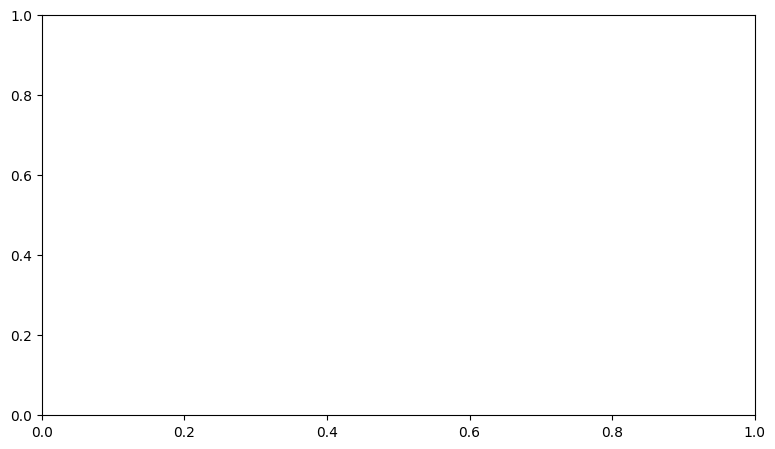

In [13]:
paper_task = summarize_paper_results(
    paper_results,
    num_simulations=NUM_SIMULATIONS,
    task=TASK_NAME,
)
ours_task = summarize_our_results(suite_results)

fig, ax = plt.subplots(figsize=(9.2, 5.2))
paper_order = list(PAPER_ALGORITHMS)
paper_plot = paper_task.set_index("algorithm").reindex(paper_order).dropna().reset_index()
our_plot = ours_task.sort_values("mean")
labels = list(paper_plot["algorithm"]) + list(our_plot["algorithm"])
means = np.concatenate([paper_plot["mean"], our_plot["mean"]])
errors = np.concatenate([paper_plot["ci95"], our_plot["ci95"].fillna(0.0)])
colors = ["0.65"] * len(paper_plot) + ["C0"] * len(our_plot)
y = np.arange(len(labels))
for yi, mean, error, color in zip(y, means, errors, colors):
    ax.errorbar(mean, yi, xerr=error, fmt="o", color=color, capsize=3)
ax.axvline(0.5, color="black", ls="--", lw=1.3, label="ideal C2ST")
ax.set(
    yticks=y,
    yticklabels=labels,
    xlabel="mean C2ST over evaluated observations (lower is better)",
    title=f"{task.name_display}, {NUM_SIMULATIONS:,} simulations",
)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25)
ax.legend()
export_exercise10_figure(fig, "paper_leaderboard")
plt.show()

comparison = compare_with_paper(
    suite_results,
    paper_results,
    num_simulations=NUM_SIMULATIONS,
    headline_method=HEADLINE_METHOD,
)
display(comparison.style.format(precision=4).hide(axis="index"))

if len(OBSERVATIONS) < 10:
    print(
        "Diagnostic only: the paper averages over ten observations. "
        "Use PROFILE='paper' or 'challenge' for a headline comparison."
    )
elif bool(comparison["beats_published_mean"].iloc[0]):
    print("The predeclared headline method beats the best published mean C2ST.")
else:
    print("The best published mean has not yet been beaten on this task.")


## 9. Assemble a multi-task campaign

Each task is intentionally run and cached separately: the challenge profile can take hours, and the 100-dimensional tasks have different modeling requirements. After rerunning the notebook with several `TASK_NAME` values, the cell below collects every saved Exercise 10 result without retraining anything.

For an honest table, only files with ten observations and a predeclared headline method should be promoted to the final comparison. Gaussian Mixture is compared to the corrected rerun, not the superseded paper rows.


In [ ]:
saved_result_files = sorted(RESULT_DIR.glob("*_c2st.csv"))
if saved_result_files:
    all_our_results = pd.concat(
        [pd.read_csv(path) for path in saved_result_files],
        ignore_index=True,
    )
    campaign_summary = summarize_our_results(all_our_results)
    display(
        campaign_summary.style.format(
            {"mean": "{:.4f}", "std": "{:.4f}", "ci95": "{:.4f}"}
        ).hide(axis="index")
    )
    print("Loaded", len(saved_result_files), "saved campaign file(s).")
else:
    print("No saved Exercise 10 result files were found yet.")


## Conclusions and limitations

This notebook converts the internal dual hNPE--hNDE demonstration into a reproducible external SBI benchmark:

- all training pairs come from the official black-box simulator;
- the number of unique simulator calls is explicit and cached;
- reference flows and corrective ratios are trained on separate subsets;
- optional cross-fitting improves sample use without increasing the simulator budget;
- bounded prior support is exact in transformed coordinates;
- raw ratio ensembles are trained with the long factor-100 learning-rate schedule and screened only by their own validation loss;
- posterior quality is measured with the official 10,000-sample, z-scored, five-fold C2ST;
- the result to beat is the best mean over the same ten observations and budget.

The frequentist Asimov and neural-importance constructions from Exercises 5--8 are not benchmarked here because `sbibm` asks a different question: posterior inference for a single observation. In Exercise 10, hNDE supplies the reusable likelihood route and the independent half of the Bayesian dual construction.

A result below the published mean is encouraging, but a publication-quality claim requires independent training seeds. It should also report wall time, peak memory, ensemble size, proposal ESS, normalization closure, and the corrected Gaussian Mixture convention. The discrete Bernoulli and ODE count tasks require an hNDE reference appropriate to probability masses (or a carefully specified dequantization); the current continuous hNDE is deliberately not misapplied to them.
